<a href="https://colab.research.google.com/github/Dashiel-png/UDE-and-SINDy-analysis-on-damped-oscillator/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import files



#t = data[:,0]
#x = data[:,1]
#y = data[:,2]
#X = data[:,1:]
#Xtrue = true[:,1:] #use it to compare to noisy data, contains all trajectory info
#dt = t[1] - t[0]



def load_data(path): #Load x,y,t from csv files
    data = np.loadtxt(path, delimiter=",", skiprows=1)

    t = data[:,0]
    x = torch.tensor(data[:,1], dtype=torch.float32)
    y = torch.tensor(data[:,2], dtype=torch.float32)
    X = data[:,1:]

    dt = t[1] - t[0]
    return x, y, dt, X, t

class DampingNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Softplus()
        )

    def forward(self, x):
        return self.net(x)

def dynamics(state, model): #Retrieves the dynamics with our current model (du/dt(t))
    x, y = state

    inp = torch.stack([x, y], dim=-1)
    g = model(inp).squeeze()

    dxdt = y
    dydt = -x + beta * x**3 - y * g

    return torch.stack([dxdt, dydt], dim=-1)

def rk4_step(state, model, dt): #Then we use rk4 to go solve the model
    k1 = dynamics(state, model)
    k2 = dynamics(state + 0.5 * dt * k1, model)
    k3 = dynamics(state + 0.5 * dt * k2, model)
    k4 = dynamics(state + dt * k3, model)

    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def simulate(model, x0, y0, steps, dt): #This simulates the data points which will be joined together with our current model for the loss function
    state = torch.tensor([x0, y0], dtype=torch.float32)
    traj = []

    for _ in range(steps):
        traj.append(state)
        state = rk4_step(state, model, dt)

    return torch.stack(traj)

#x_t = torch.tensor(x[:-1], dtype=torch.float32)
#y_t = torch.tensor(y[:-1], dtype=torch.float32)

def evaluate(model, x_true, y_true, dt):
    with torch.no_grad():
        pred = simulate(model, x_true[0], y_true[0], len(x_true), dt)

    mse = torch.mean(
        (pred[:,0] - x_true)**2 +
        (pred[:,1] - y_true)**2
    ).item()

    return mse


beta = 1.0
model = DampingNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
class NN():
  def UDE(model, optimizer, x_data, y_data, dt, epochs):
    n_steps = len(x_data)
    losses = []
    for epoch in range(epochs):
        pred_traj = simulate(model, x_data[0], y_data[0], n_steps, dt) #Simulate model to get predicted trajectories

        x_pred = pred_traj[:, 0]
        y_pred = pred_traj[:, 1]

        loss = torch.mean((x_pred - x_data)**2 + (y_pred - y_data)**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
        losses.append(loss.item())
    return model, losses
  def multiUDE(model, optimizer, x_data1, y_data1, x_data2, y_data2, dt, epochs): #Used for 2 different starting conditions
    losses = []
    for epoch in range(epochs):
      dataset = random.choice([[x_data1, y_data1], [x_data2, y_data2]]) #Choose a random initial point to train model upon each epoch to keep data set balanced
      x_data = dataset[0]
      y_data = dataset[1]

      n_steps = len(x_data)
      pred_traj = simulate(model, x_data[0], y_data[0], n_steps, dt) #Simulate model to get predicted trajectories

      x_pred = pred_traj[:, 0]
      y_pred = pred_traj[:, 1]

      loss = torch.mean((x_pred - x_data)**2 + (y_pred - y_data)**2)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if epoch % 10 == 0:
          print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
      losses.append(loss.item())
    return model, losses





In [4]:
pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 7.3 MB/s eta 0:00:00


# Training the UDE on varying noises

In [25]:
models = {}
results = {}
losshistories = {}

beta = 1.0

noises = [0, 0.01, 0.05, 0.1]

for sigma in noises:
    model = DampingNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    print(f"\nTraining with noise σ = {sigma}")

    train_path = f"datasd{sigma}.csv"
    x_train, y_train, dt, X, t = load_data(train_path)

    model, lossdata = NN.UDE(model, optimizer, x_train, y_train, dt, 500) #using 500 epochs for now

    models[sigma] = model #Store the model for testing later
    losshistories[sigma] = lossdata


plt.figure()

for sigma, losses in losshistories.items():
    plt.plot(losses, label=f"σ={sigma}")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epoch (UDE)")
plt.legend()
plt.savefig('UDE1.1.png')
plt.show()




Training with noise σ = 0
Epoch 0, Loss: 0.019756
Epoch 10, Loss: 0.015624
Epoch 20, Loss: 0.011970
Epoch 30, Loss: 0.008863
Epoch 40, Loss: 0.006332
Epoch 50, Loss: 0.004360
Epoch 60, Loss: 0.002896
Epoch 70, Loss: 0.001862
Epoch 80, Loss: 0.001167
Epoch 90, Loss: 0.000721


KeyboardInterrupt: 

Test data

σ=0, Test MSE=7.986460695974529e-05
σ=0.01, Test MSE=3.345710865687579e-05
σ=0.05, Test MSE=0.0005049541941843927
σ=0.1, Test MSE=0.0010847443481907248


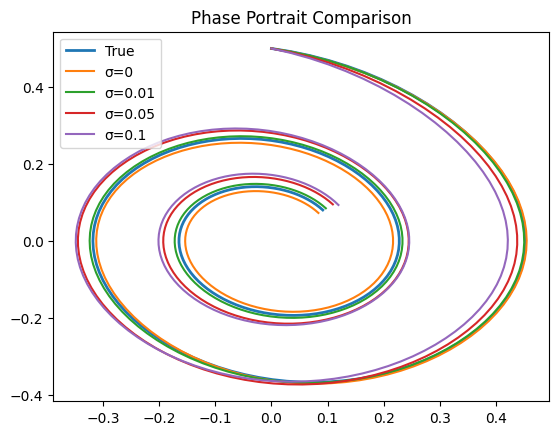

In [38]:
x_test, y_test, dt, X, t = load_data("test1.csv")

plt.figure()

# true trajectory
plt.plot(x_test.numpy(), y_test.numpy(), label="True", linewidth=2)

for sigma, model in models.items():
    mse = evaluate(model, x_test, y_test, dt)
    results[sigma] = mse
    with torch.no_grad():
        pred = simulate(model, x_test[0], y_test[0], len(x_test), dt)

    plt.plot(pred[:,0].numpy(), pred[:,1].numpy(), label=f"σ={sigma}")

    print(f"σ={sigma}, Test MSE={mse}")


plt.legend()
plt.title("Phase Portrait Comparison")
plt.savefig('UDE2.1.png')
plt.show()

# The SINDy model

In [5]:
import pysindy as ps
from pysindy.differentiation import SmoothedFiniteDifference

sindymodels = {}

beta = 1.0

noises = [0, 0.01, 0.05, 0.1]

thresholds = np.logspace(-4, -1, 10) #Use thresholds to find best Sindy


def SINDYwithsweep(path, mod = None): #fit SINDy model on specified csv and sweep over thresholds to determine best one
  x, y, dt, X, t = load_data(path)


  diff = ps.SmoothedFiniteDifference()
  Xdot = diff._differentiate(X, t)

  library = ps.PolynomialLibrary(degree=3) + ps.FourierLibrary() #Adding trig functions
  #library = ps.PolynomialLibrary(degree=3)

  optimizer = ps.STLSQ(threshold=0.08)  # sparsity control

  bestmodel = mod
  best_score = float('inf')
  for thresh in thresholds:
    model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer
    )

    model.fit(X, t=t, x_dot = Xdot) #use our calculated smoothed derivative
    X_sim = model.simulate(X[0], t)
    error = np.mean((X_sim - X)**2)
    if error < best_score:
      best_score = error
      best_model = model
  print("\nDiscovered system:")
  model.print()
  return best_model

for sigma in noises:
  print(f"\nTraining with noise σ = {sigma}")
  sindymodels[sigma] = SINDYwithsweep(f"datasd{sigma}.csv")



#print("\nDiscovered system:")
#model.print()

#X_sim = model.simulate(X[0], t)

#plt.figure()
#plt.plot(t, X[:, 0], label="Data x")
#plt.plot(t, Xtrue[:, 0], label="True x")
#plt.plot(t, X_sim[:, 0], '--', label="SINDy x")
#plt.legend()
#plt.xlabel("t")
#plt.ylabel("x")
#plt.title("SINDy vs Data")

#plt.figure()
#plt.plot(X[:, 0], X[:, 1], label="Data")
#plt.plot(Xtrue[:, 0], Xtrue[:, 1], label="True x")
#plt.plot(X_sim[:, 0], X_sim[:, 1], '--', label="SINDy")
#plt.legend()
#plt.xlabel("x")
#plt.ylabel("y")
#plt.title("Phase Portrait")

#plt.show()



Training with noise σ = 0

Discovered system:
(x0)' =  1.006 x1 + -0.006 sin(1 x1)
(x1)' = -0.565 x0 + -0.192 x1 +  0.926 x0^3 +  0.002 x0 x1^2 + -0.435 sin(1 x0) + -0.008 sin(1 x1)

Training with noise σ = 0.01

Discovered system:
(x0)' =  1.307 x1 + -0.317 sin(1 x1)
(x1)' = -297.947 x0 +  0.359 x1 +  0.044 x0^2 +  49.680 x0^3 + -0.075 x0 x1^2 +  296.991 sin(1 x0) + -0.565 sin(1 x1)

Training with noise σ = 0.05

Discovered system:
(x0)' =  1801.746 x1 + -1.032 x0 x1 +  0.807 x1^2 + -2.094 x0 x1^2 + -297.742 x1^3 + -1800.577 sin(1 x1)
(x1)' = -890.928 x0 +  0.616 x0^2 + -2.197 x0 x1 +  0.413 x1^2 +  148.094 x0^3 +  4.315 x0^2 x1 +  889.573 sin(1 x0)

Training with noise σ = 0.1

Discovered system:
(x0)' = -103.520 1 + -682.511 x0 +  3044.746 x1 +  0.321 x0^2 + -1.772 x0 x1 +  51.896 x1^2 +  111.763 x0^3 + -0.284 x0^2 x1 + -0.511 x0 x1^2 + -500.287 x1^3 +  682.409 sin(1 x0) + -3043.847 sin(1 x1) +  103.512 cos(1 x1)
(x1)' =  372.623 1 + -3525.003 x0 + -181.000 x0^2 + -3.313 x0 x1 +  0

Phase portrait of the system on our test data

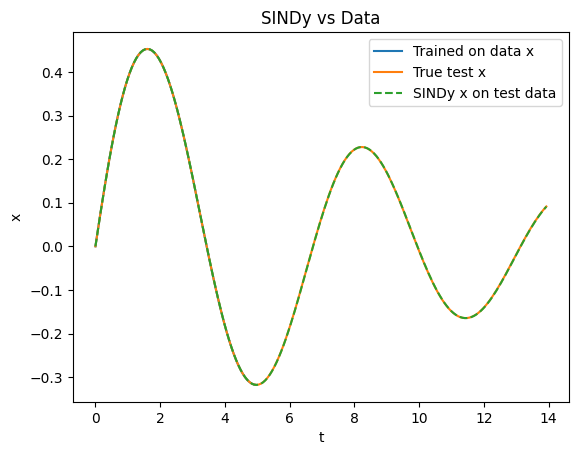

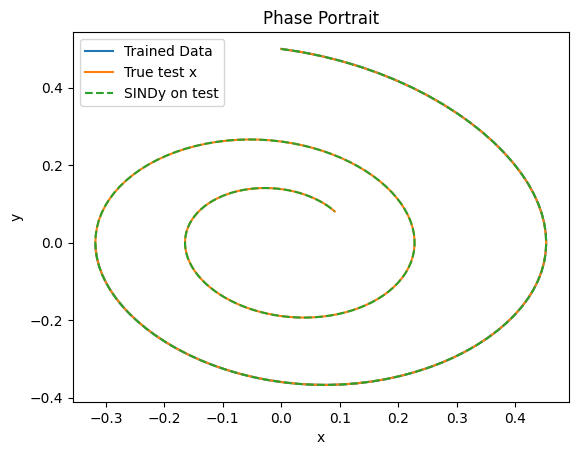

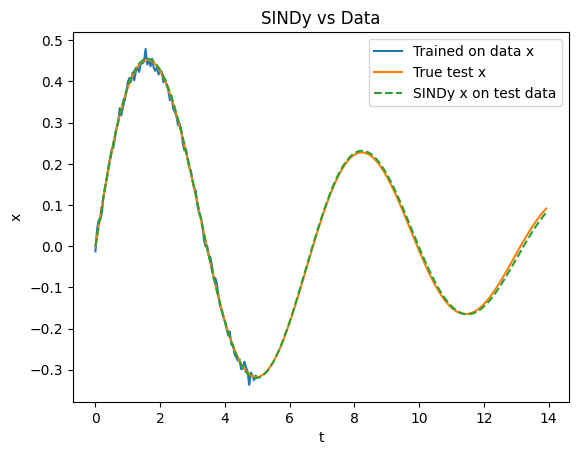

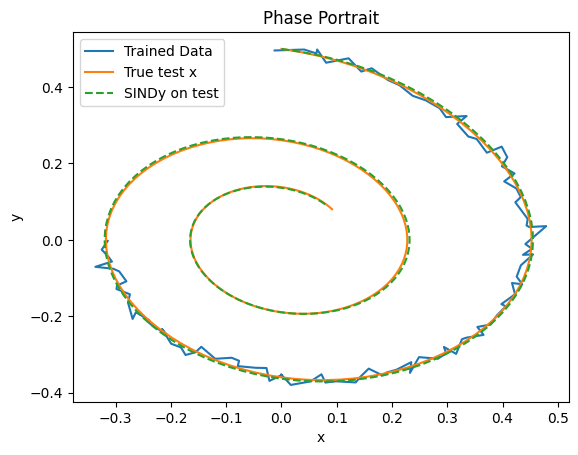

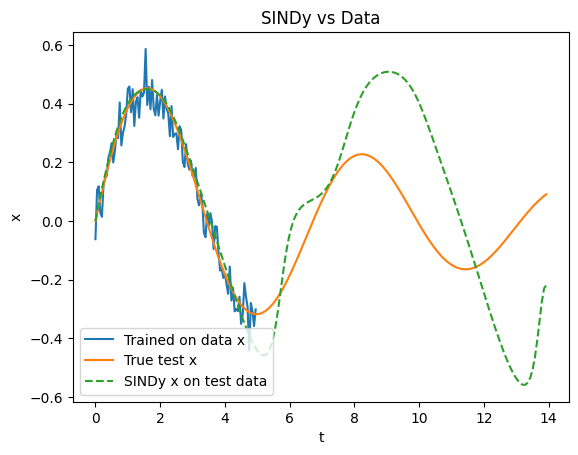

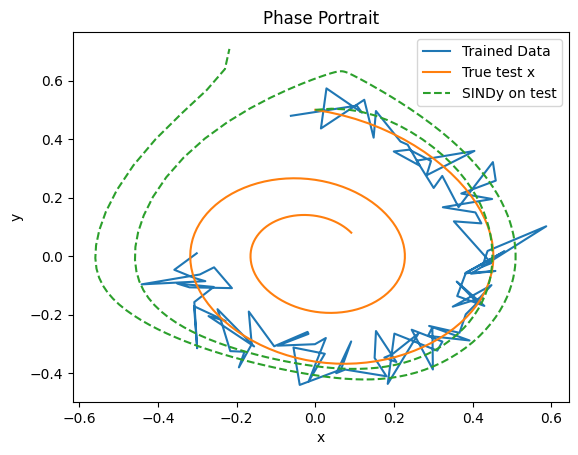

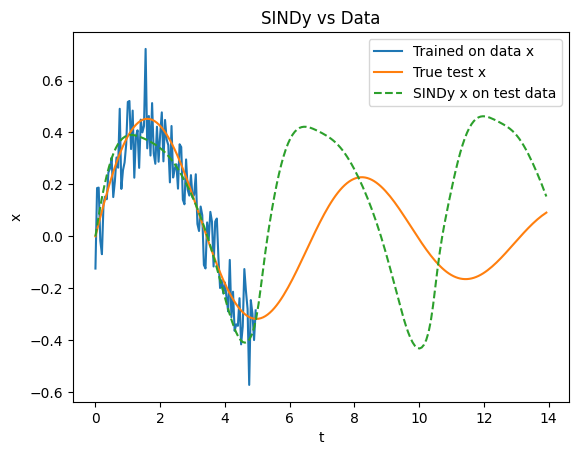

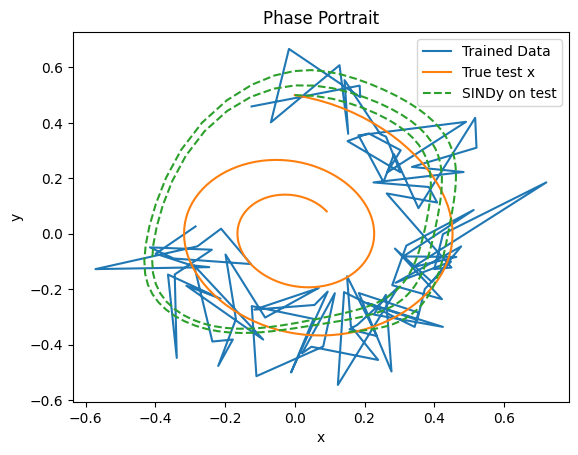

In [6]:
x_test, y_test, dt, X_test, t_test = load_data("test1.csv")

i = 0
for sigma in noises:
  i+=1
  X_sim = sindymodels[sigma].simulate(X_test[0], t_test, integrator="odeint")
  x_trained, y_trained, dt_tr, X_trained, t_trained = load_data(f"datasd{sigma}.csv")


  plt.figure()
  plt.plot(t_trained, X_trained[:, 0], label="Trained on data x")
  plt.plot(t_test, X_test[:, 0], label="True test x")
  plt.plot(t_test, X_sim[:, 0], '--', label="SINDy x on test data")
  plt.legend()
  plt.xlabel("t")
  plt.ylabel("x")
  plt.title("SINDy vs Data")
  plt.savefig(f'Sindyim1.{i}.png')

  plt.show()
  i+=1

  plt.figure()
  plt.plot(X_trained[:, 0], X_trained[:, 1], label="Trained Data")
  plt.plot(X_test[:, 0], X_test[:, 1], label="True test x")
  plt.plot(X_sim[:, 0], X_sim[:, 1], '--', label="SINDy on test")
  plt.legend()
  plt.xlabel("x")
  plt.ylabel("y")
  plt.title("Phase Portrait")
  plt.savefig(f'Sindyim1.{i}.png')

  plt.show()

#plt.show()

#plt.figure()
#plt.plot(X[:, 0], X[:, 1], label="Data")
#plt.plot(Xtrue[:, 0], Xtrue[:, 1], label="True x")
#plt.plot(X_sim[:, 0], X_sim[:, 1], '--', label="SINDy")
#plt.legend()
#plt.xlabel("x")
#plt.ylabel("y")
#plt.title("Phase Portrait")

#plt.show()

#plt.figure()
#plt.plot(t, X[:, 0], label="Data x")
#plt.plot(t, Xtrue[:, 0], label="True x")
#plt.plot(t, X_sim[:, 0], '--', label="SINDy x")
#plt.legend()
#plt.xlabel("t")
#plt.ylabel("x")
#plt.title("SINDy vs Data")

#plt.figure()
#plt.plot(X[:, 0], X[:, 1], label="Data")
#plt.plot(Xtrue[:, 0], Xtrue[:, 1], label="True x")
#plt.plot(X_sim[:, 0], X_sim[:, 1], '--', label="SINDy")
#plt.legend()
#plt.xlabel("x")
#plt.ylabel("y")
#plt.title("Phase Portrait")

#plt.show()

# Training on a new initial condition

### UDE on x_0 = (-1,0.5)


Training with noise σ = 0
Epoch 0, Loss: 0.223084
Epoch 10, Loss: 0.220454
Epoch 20, Loss: 0.090305
Epoch 30, Loss: 0.216140
Epoch 40, Loss: 0.088396
Epoch 50, Loss: 0.087299
Epoch 60, Loss: 0.208959
Epoch 70, Loss: 0.205934
Epoch 80, Loss: 0.202604
Epoch 90, Loss: 0.082200
Epoch 100, Loss: 0.080563
Epoch 110, Loss: 0.078804
Epoch 120, Loss: 0.076880
Epoch 130, Loss: 0.180741
Epoch 140, Loss: 0.072393
Epoch 150, Loss: 0.069924
Epoch 160, Loss: 0.156301
Epoch 170, Loss: 0.064801
Epoch 180, Loss: 0.062376
Epoch 190, Loss: 0.060259
Epoch 200, Loss: 0.079119
Epoch 210, Loss: 0.058221
Epoch 220, Loss: 0.058249
Epoch 230, Loss: 0.058188
Epoch 240, Loss: 0.092894
Epoch 250, Loss: 0.091864
Epoch 260, Loss: 0.057784
Epoch 270, Loss: 0.057640
Epoch 280, Loss: 0.057497
Epoch 290, Loss: 0.085235
Epoch 300, Loss: 0.083516
Epoch 310, Loss: 0.057081
Epoch 320, Loss: 0.079894
Epoch 330, Loss: 0.056813
Epoch 340, Loss: 0.075888
Epoch 350, Loss: 0.056556
Epoch 360, Loss: 0.072553
Epoch 370, Loss: 0.056

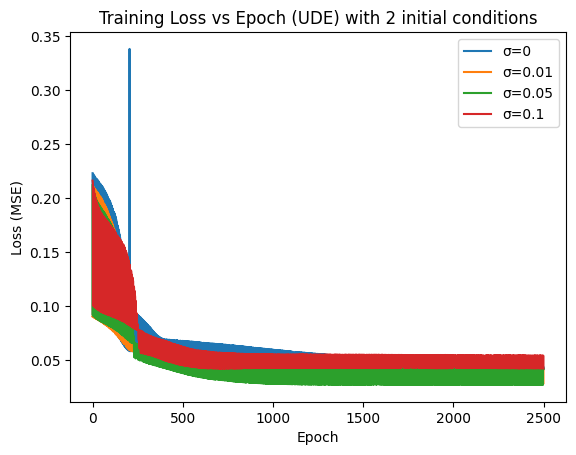

In [11]:
#You should have already trained on the first initial condition before running this
newmodels = {}
newlosshistories = {}
beta = 1.0

noises = [0, 0.01, 0.05, 0.1]

for sigma in noises:
    model = DampingNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    print(f"\nTraining with noise σ = {sigma}")


    train_path1 = f"datasd{sigma}.csv"
    train_path2 = f"data2sd{sigma}.csv" #data2 for 2nd initial cond x0
    x1_train, y1_train, dt1, X1, t1 = load_data(train_path1)
    x2_train, y2_train, dt2, X2, t2 = load_data(train_path2)

    model, lossdata = NN.multiUDE(model, optimizer, x1_train, y1_train, x2_train, y2_train, dt, 2500) #We need to use more iterations due to increased complexity

    newmodels[sigma] = model #Store the model for testing later
    newlosshistories[sigma] = lossdata


plt.figure()

for sigma, losses in newlosshistories.items():
    plt.plot(losses, label=f"σ={sigma}")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epoch (UDE) with 2 initial conditions")
plt.legend()
plt.savefig('UDE2.1.png')
plt.show()

## Testing the newly trained data on the UDE

σ=0, Test MSE=0.041176341474056244
σ=0.01, Test MSE=0.045893531292676926
σ=0.05, Test MSE=0.04123003035783768
σ=0.1, Test MSE=0.032238852232694626


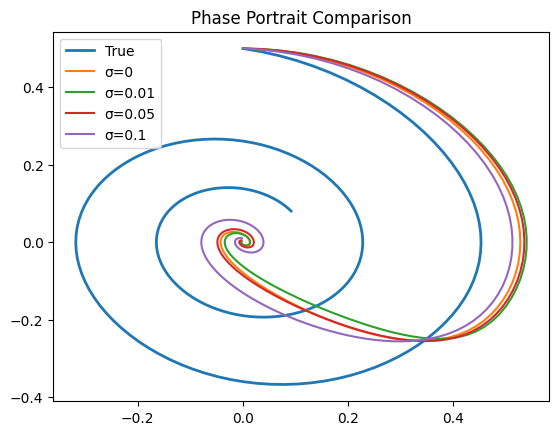

In [12]:

plt.figure()
x_test, y_test, dt, X, t = load_data("test1.csv")
newresults = {}



# true trajectory
plt.plot(x_test.numpy(), y_test.numpy(), label="True", linewidth=2)

for sigma, model in newmodels.items():
    mse = evaluate(model, x_test, y_test, dt)
    newresults[sigma] = mse
    with torch.no_grad():
        pred = simulate(model, x_test[0], y_test[0], len(x_test), dt)

    plt.plot(pred[:,0].numpy(), pred[:,1].numpy(), label=f"σ={sigma}")

    print(f"σ={sigma}, Test MSE={mse}")



plt.legend()
plt.title("Phase Portrait Comparison")
plt.savefig('UDE2.2.png')
plt.show()

### Now we train SINDy models on new initial condition

In [7]:
#Remember to have already trained original

newsindymodels = {}
#Have to change function to act on 2 initial conditions
def multiSINDYwithsweep(path1, path2, mod = None): #fit SINDy model on specified csv and sweep over thresholds to determine best one
  x1, y1, dt1, X1, t1 = load_data(path1)
  x2, y2, dt2, X2, t2 = load_data(path2)


  diff = ps.SmoothedFiniteDifference()
  Xdot1 = diff._differentiate(X1, t1)
  Xdot2 = diff._differentiate(X2, t2)

  library = ps.PolynomialLibrary(degree=3) + ps.FourierLibrary() #Adding trig functions
  #library = ps.PolynomialLibrary(degree=3)

  optimizer = ps.STLSQ(threshold=0.08)  # sparsity control

  bestmodel = mod
  best_score = float('inf')
  for thresh in thresholds:
    model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer
    )

    model.fit([X1,X2], t=[t1,t2], x_dot = [Xdot1,Xdot2]) #use our calculated smoothed derivative
    X_sim1 = model.simulate(X1[0], t1)
    X_sim2 = model.simulate(X2[0], t2)
    error = np.mean((X_sim1 - X1)**2 + (X_sim2 - X2)**2)
    if error < best_score:
      best_score = error
      best_model = model
  print("\nDiscovered system:")
  model.print()
  return best_model

for sigma in noises:
  print(f"\nTraining with noise σ = {sigma}")
  newsindymodels[sigma] = multiSINDYwithsweep(f"data2sd{sigma}.csv", f"datasd{sigma}.csv")


Training with noise σ = 0

Discovered system:
(x0)' =  1.703 x1 + -0.114 x1^3 + -0.704 sin(1 x1)
(x1)' = -0.954 x0 + -0.203 x1 +  0.992 x0^3 + -0.046 sin(1 x0) +  0.003 sin(1 x1)

Training with noise σ = 0.01

Discovered system:
(x0)' =  0.882 x1 +  0.121 sin(1 x1)
(x1)' =  17.463 x0 + -0.203 x1 + -1.964 x0^3 + -18.480 sin(1 x0)

Training with noise σ = 0.05

Discovered system:
(x0)' =  48.426 x1 +  0.271 x1^2 + -8.345 x1^3 + -47.367 sin(1 x1)
(x1)' =  92.156 x0 + -13.886 x0^3 +  0.245 x0^2 x1 +  0.451 x0 x1^2 + -93.297 sin(1 x0) + -0.225 sin(1 x1)

Training with noise σ = 0.1

Discovered system:
(x0)' = -74.710 x1 + -0.413 x0 x1 +  0.120 x1^2 +  0.349 x0 x1^2 +  11.116 x1^3 +  0.279 cos(1 x0) +  75.979 sin(1 x1) + -0.245 cos(1 x1)
(x1)' = -0.040 1 +  128.672 x0 + -161.410 x1 + -0.085 x0^2 + -0.103 x1^2 + -19.585 x0^3 +  1.123 x0^2 x1 +  1.208 x0 x1^2 +  26.364 x1^3 + -129.937 sin(1 x0) +  0.062 cos(1 x0) +  161.129 sin(1 x1)


### Plotting the results

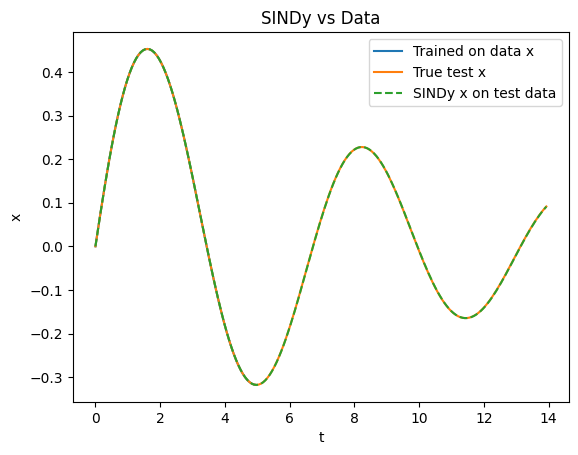

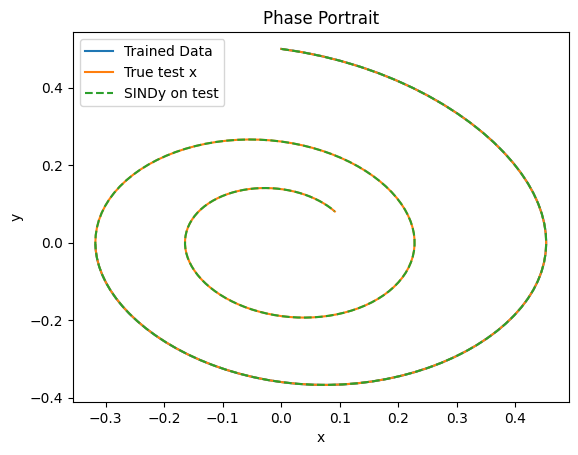

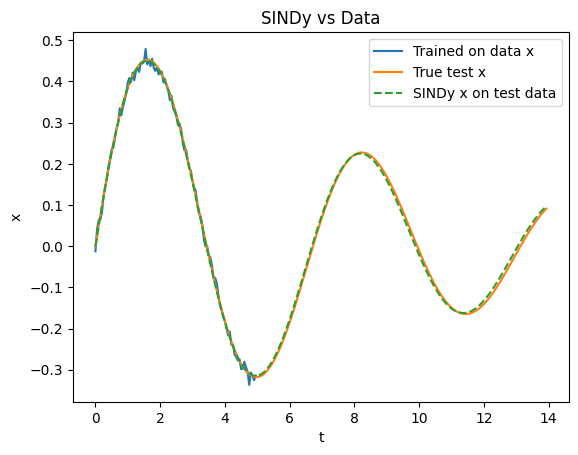

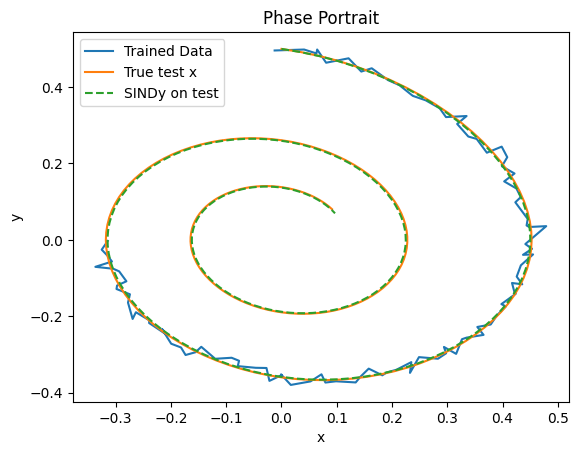

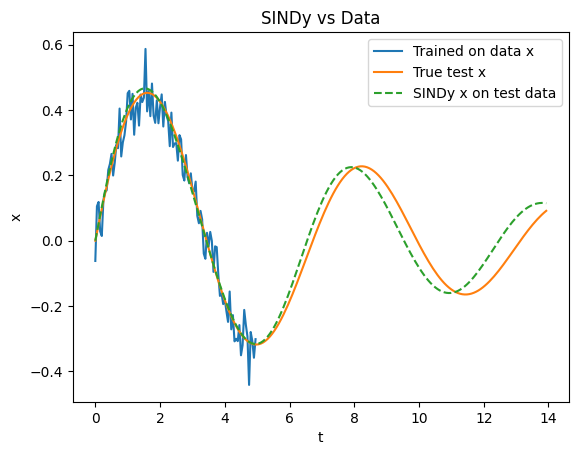

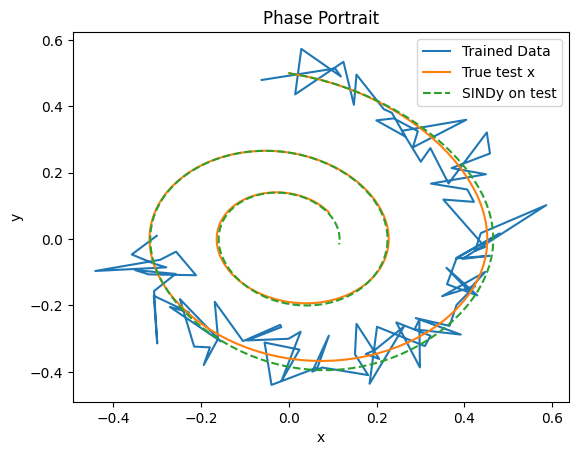

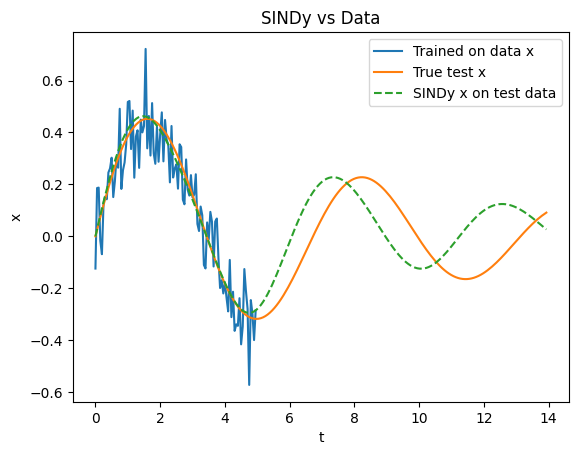

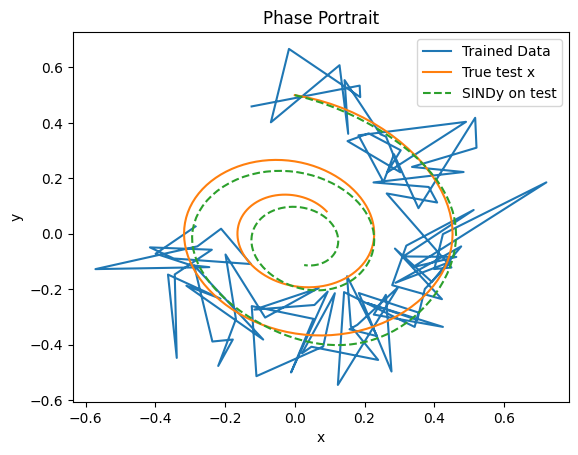

In [8]:
i = 0
for sigma in noises:
  i += 1
  X_sim = newsindymodels[sigma].simulate(X_test[0], t_test, integrator="odeint")
  x_trained, y_trained, dt_tr, X_trained, t_trained = load_data(f"datasd{sigma}.csv")


  plt.figure()
  plt.plot(t_trained, X_trained[:, 0], label="Trained on data x")
  plt.plot(t_test, X_test[:, 0], label="True test x")
  plt.plot(t_test, X_sim[:, 0], '--', label="SINDy x on test data")
  plt.legend()
  plt.xlabel("t")
  plt.ylabel("x")
  plt.title("SINDy vs Data")
  plt.savefig(f"Sindyim2.{i}.png")

  plt.show()
  i += 1

  plt.figure()
  plt.plot(X_trained[:, 0], X_trained[:, 1], label="Trained Data")
  plt.plot(X_test[:, 0], X_test[:, 1], label="True test x")
  plt.plot(X_sim[:, 0], X_sim[:, 1], '--', label="SINDy on test")
  plt.legend()
  plt.xlabel("x")
  plt.ylabel("y")
  plt.title("Phase Portrait")
  plt.savefig(f"Sindyim2.{i}.png")

  plt.show()